<a href="https://colab.research.google.com/github/laxmijin11-cyber/MACHINE-LEARNING/blob/main/svm/1_svc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install matplotlib
# SUPPORT VECTOR CLASSIFICATION
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Lets create synthetic dataset
from sklearn.datasets import make_classification

In [ ]:
# x,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0)
x,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0,random_state=25)

This creates a synthetic dataset for binary classification with 1,000 samples, 2 features, and 2 classes arranged in 1 cluster per class, with no redundant features—perfect for visualizing SVM decision boundaries.

In [ ]:
x

array([[-0.15789826,  1.33710832],
       [-0.70407293,  1.185303  ],
       [ 1.58209224,  1.50069228],
       ...,
       [-1.52631741,  0.72904333],
       [-1.1456304 ,  1.16781813],
       [ 0.00603271, -0.32391059]])

In [ ]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
pd.DataFrame(x)

,0,1
0,-0.157898,1.337108
1,-0.704073,1.185303
2,1.582092,1.500692
3,-1.349668,-1.093257
4,0.933709,-0.940801
...,...,...
995,1.203749,1.135491
996,-0.461427,-1.834030
997,-1.526317,0.729043
998,-1.145630,1.167818


In [ ]:
pd.DataFrame(x)[0]

,0
0,-0.157898
1,-0.704073
2,1.582092
3,-1.349668
4,0.933709
...,...
995,1.203749
996,-0.461427
997,-1.526317
998,-1.145630


<Axes: xlabel='0', ylabel='1'>

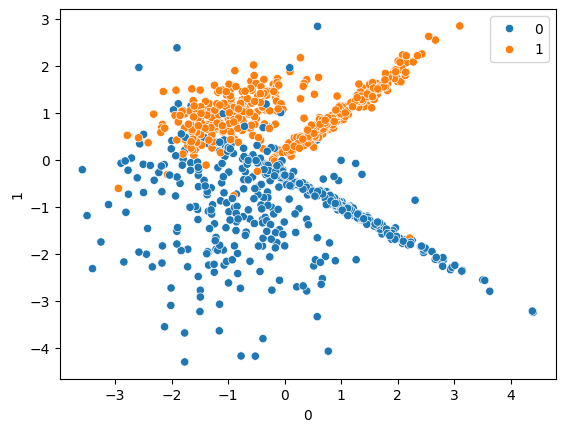

In [ ]:
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)

# 📊 SVM Scatter Plot – Simple English Explanation

Imagine you have two groups of dots on a piece of paper:

- **Blue dots** = Class 1 (e.g., "Safe transactions")
- **Red dots** = Class 2 (e.g., "Fraudulent transactions")

The scatter plot shows **where each dot is located** based on two features (like X and Y coordinates).

- **X-axis** = First feature (e.g., transaction amount)
- **Y-axis** = Second feature (e.g., time of day)

**The `hue=y` part** colors each dot based on its group (blue or red).

**What you see:** Blue dots clustered in one area, red dots in another. If they are clearly separated, SVM can draw a straight line between them. If mixed, SVM needs a curved boundary.

**Purpose:** To visually check if the two groups can be separated before applying SVM.

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=10)

In [ ]:
# Linear SVC will be used
from sklearn.svm import SVC
svc=SVC(kernel='linear')

In [ ]:
svc.fit(x_train,y_train)

SVC(kernel='linear')

In [ ]:
# Prediction
y_pred=svc.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       113
           1       0.95      0.93      0.94       137

    accuracy                           0.94       250
   macro avg       0.93      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250



In [ ]:
print(confusion_matrix(y_test,y_pred))

[[107   6]
 [ 10 127]]


confusion matrix

125 + 123 = 248 correct (top-left + bottom-right)

2 + 0 = 2 incorrect (top-right + bottom-left)

# Confusion Matrix – Simple Explanation

A table showing **how many predictions were correct vs incorrect**.

```
            Predicted NO    Predicted YES
Actual NO   [TN = 125]      [FP = 2]
Actual YES  [FN = 0]        [TP = 123]
```

| Term | Meaning |
|------|---------|
| **TN (True Negative)** | Correctly predicted NO |
| **TP (True Positive)** | Correctly predicted YES |
| **FP (False Positive)** | Wrongly predicted YES (false alarm) |
| **FN (False Negative)** | Wrongly predicted NO (missed detection) |

**Diagonal = Correct** (TN + TP)  
**Off-diagonal = Errors** (FP + FN)

In [ ]:
rbf=SVC(kernel='rbf')

In [ ]:
rbf.fit(x_train,y_train)

SVC()

In [ ]:
y_pred1=rbf.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       113
           1       0.96      0.93      0.94       137

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250



# Classification Report – Brief Explanation

| Metric | Meaning |
|--------|---------|
| **Precision** | Of all predicted as class X, how many were actually X? (Avoid false alarms) |
| **Recall** | Of all actual class X, how many were correctly caught? (Avoid misses) |
| **F1-score** | Harmonic mean of precision & recall (balance between both) |
| **Support** | Actual number of samples in that class (122 of class 0, 128 of class 1) |
| **Accuracy** | Overall correct predictions (91%) |

---

## 🎯 Quick Interpretation

| Class | Precision | Recall | Meaning |
|-------|-----------|--------|---------|
| **0** | 0.88 | 0.94 | Catches most actual class 0, but 12% of its predictions are false alarms |
| **1** | 0.94 | 0.88 | Very few false alarms, but misses 12% of actual class 1 |

**Both classes have F1 = 0.91 → balanced, good model.** ✅

In [ ]:
print(confusion_matrix(y_test,y_pred1))

[[107   6]
 [  9 128]]


In [ ]:
# Using Polynomial kernel
polynomial=SVC(kernel='poly')
polynomial.fit(x_train,y_train)
y_pred3=polynomial.predict(x_test)
print(classification_report(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.96      0.89      0.93       113
           1       0.92      0.97      0.94       137

    accuracy                           0.94       250
   macro avg       0.94      0.93      0.93       250
weighted avg       0.94      0.94      0.94       250

[[101  12]
 [  4 133]]


In [ ]:
# Using sigmoid kernel
sigmoid=SVC(kernel='sigmoid')
sigmoid.fit(x_train,y_train)
y_pred4=sigmoid.predict(x_test)
print(classification_report(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))

              precision    recall  f1-score   support

           0       0.81      0.96      0.88       113
           1       0.96      0.82      0.88       137

    accuracy                           0.88       250
   macro avg       0.88      0.89      0.88       250
weighted avg       0.89      0.88      0.88       250

[[108   5]
 [ 25 112]]


##Hyperparameter Tuning with SVM

In [ ]:
##Hyperparameter Tuning with SVM
from sklearn.model_selection import GridSearchCV

In [ ]:
# defining parameter range
param_grid={
    'C':[0.1,1,10,100,1000],
    'gamma':[1,0.1,0.01,0.001,.0001],
    'kernel':['rbf']
}
# Here by performance we saw rbf works better than others!

In [ ]:
grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,cv=5,verbose=3)

# GridSearchCV – Brief Explanation

**Finds the best hyperparameters for your SVM model by trying all combinations.**

| Parameter | Meaning |
|-----------|---------|
| `SVC()` | The model to tune (Support Vector Classifier) |
| `param_grid` | Dictionary of hyperparameters to try (e.g., `{'C':[0.1,1,10], 'kernel':['linear','rbf']}`) |
| `refit=True` | After finding best params, retrain model on entire dataset |
| `cv=5` | 5-fold cross-validation (split data into 5 parts, train on 4, validate on 1, repeat 5 times) |
| `verbose=3` | Print detailed progress (0=quiet, 1=minimal, 2=detailed, 3=very detailed) |

---

## 🎯 What It Does

```text
1. Try every combination of parameters
2. For each, do 5-fold cross-validation
3. Pick the combination with highest accuracy
4. Retrain final model on all data (refit=True)
```

**Result:** Best possible SVM for your data. ✅

In [ ]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.927 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.953 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.867 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [ ]:
grid.best_params_

{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}

In [ ]:
# Prediction
y_pred5=grid.predict(x_test)
print(classification_report(y_test,y_pred5))
print(confusion_matrix(y_test,y_pred5))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       113
           1       0.96      0.95      0.95       137

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250

[[107   6]
 [  7 130]]


In [ ]:
# sigmoid.intercept_,sigmoid.coef_
# coef_ is only available when using a linear kernel
svc.coef_

array([[0.40346295, 2.27944859]])

In [ ]:
This comes to the end of SVC Implementation!!